In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.path import Path


In [2]:
dfs = []
key = []
lab = []
subtitles = ['P113', 'OS-C', 'Buforin-2']

dfs.append(pd.read_csv('AMP_P113.csv').sample(frac = 1))
key.append([r'PolyA, ng/uL', r'P113, uM'])
lab.append([r'[RNA](ng/ul)', r'[AMP](uM)'])

dfs.append(pd.read_csv('AMP_Os-C.csv').sample(frac = 1))
key.append([r'PolyA, ng/uL', r'Os-C, uM'])
lab.append([r'[RNA](ng/ul)', r'[AMP](uM)'])

dfs.append(pd.read_csv('AMP_Buforin-2.csv').sample(frac = 1))
key.append([r'PolyA, ng/uL', r'Buforin-2, uM'])
lab.append([r'[RNA](ng/ul)', r'[AMP](uM)'])

# Store AMP names
variants = ["P113", "Os-C", "Buforin-2"]

In [3]:
# Definition of phase boundary points extraction function
def phase_boundary(xbins, ybins, P_field,
                   boundary_range=(0.2, 0.8),
                   smooth_sigma=1.0):
    if smooth_sigma > 0:
        P_smooth = gaussian_filter(P_field, sigma=smooth_sigma, mode='reflect')
    else:
        P_smooth = P_field.copy()

    XX, YY = np.meshgrid(xbins, ybins, indexing='xy')

    boundary_mask = (P_smooth >= boundary_range[0]) & (P_smooth <= boundary_range[1])
    bx = XX[boundary_mask]
    by = YY[boundary_mask]

    return bx, by


# Function to plot phase separation probability heat map
def phase_separation_probability(
    ax, df,
    xcol="", ycol="", f_col="",
    bins=80, smooth_sigma=1.0,
    slab_col=None, slab_val=None, slab_thickness=None,
    cmap="viridis", vmin=0.0, vmax=1.0
):

    # slab filtering
    if slab_col is not None and slab_val is not None and slab_thickness is not None:
        section = df[
            (df[slab_col] >= slab_val) &
            (df[slab_col] < slab_val + slab_thickness)
        ].copy()
    else:
        section = df.copy()

    # separate classes
    df_sep = section[section[f_col] == True]
    df_dil = section[section[f_col] == False]

    # histograms
    H_sep, xedges, yedges = np.histogram2d(
        df_sep[xcol], df_sep[ycol], bins=bins
    )
    H_dil, _, _ = np.histogram2d(
        df_dil[xcol], df_dil[ycol], bins=[xedges, yedges]
    )

    # smoothing
    if smooth_sigma > 0:
        H_sep = gaussian_filter(H_sep, sigma=smooth_sigma, mode="reflect")
        H_dil = gaussian_filter(H_dil, sigma=smooth_sigma, mode="reflect")

    # probability field
    H_total = H_sep + H_dil
    with np.errstate(invalid="ignore", divide="ignore"):
        P_sep = np.where(H_total > 0, H_sep / H_total, np.nan)

    # mask empty bins
    P_plot = np.ma.array(P_sep, mask=np.isnan(P_sep))

    # plot on axis
    im = ax.pcolormesh(
        xedges, yedges, P_plot.T,
        shading="auto",
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        rasterized=True
    )

    return im, {
        "section": section,
        "H_sep": H_sep,
        "H_dil": H_dil,
        "P_sep": P_sep,
        "xedges": xedges,
        "yedges": yedges
    }


In [4]:
# ------------------------------------------------
# Build probability fields
# ------------------------------------------------
PS = []
RNAbins = np.linspace(1, 1500, 60)
AMPbins = np.linspace(1, 180, 60)
dRNA = RNAbins[1] - RNAbins[0]
dAMP = AMPbins[1] - AMPbins[0]

for i in range(3):
    _df = dfs[i]
    _x = _df[key[i][0]].values
    _y = _df[key[i][1]].values
    _feature = _df['feature'].values.astype(int)

    ps = np.zeros((len(RNAbins), len(AMPbins)))

    for j in range(len(RNAbins)):
        print(f'{i}-{j:02d}', end='\r')
        for k in range(len(AMPbins)):
            mask = (
                (RNAbins[j] - dRNA/2 < _x) & (_x < RNAbins[j] + dRNA/2) &
                (AMPbins[k] - dAMP/2 < _y) & (_y < AMPbins[k] + dAMP/2)
            )

            if np.any(mask):
                ps[j, k] = np.mean(_feature[mask])

    PS.append(ps)

print()


# ------------------------------------------------
# Extract boundary points
# ------------------------------------------------
COORS = []

for i in range(3):
    ps = PS[i].T

    bx, by = phase_boundary(
        xbins=RNAbins,
        ybins=AMPbins,
        P_field=ps,
        boundary_range=(0.45, 0.55),
        smooth_sigma=1.0
    )

    COORS.append([bx, by])


# ----------------------------------
# Global fit data prep + counting
# N_RAW[i]   = len(dfs[i])  (raw scan points)
# N_BOUND[i] = number of boundary points actually used in fitting
# ----------------------------------
_x_list, _y_list = [], []
N_RAW, N_BOUND = [], []

for i in range(3):
    # raw count
    if "dfs" in globals():
        N_RAW.append(len(dfs[i]))
    else:
        N_RAW.append(np.nan)

    # boundary data from COORS
    _x = np.asarray(COORS[i][0], dtype=float)
    _y = np.asarray(COORS[i][1], dtype=float)

    # remove NaN/inf first
    good = np.isfinite(_x) & np.isfinite(_y)
    _x = _x[good]
    _y = _y[good]

    # define trapezoid vertices
    if i in [0, 1]:
        trap = np.array([
            [250,  60],
            [250, 200],
            [1500, 200],
            [1500, 150]
        ])
    else:  # i == 2
        trap = np.array([
            [100,  80],
            [100, 200],
            [1000, 200],
            [1000, 150]
        ])

    pts = np.column_stack([_x, _y])

    # keep points outside trapezoid
    trap_mask = ~Path(trap).contains_points(pts)

    _x = _x[trap_mask]
    _y = _y[trap_mask]

    _x_list.append(_x)
    _y_list.append(_y)

    N_BOUND.append(len(_x))

# Convert to array
N_RAW = np.array(N_RAW)
N_BOUND = np.array(N_BOUND)

print("\nData counts (raw vs boundary-used):")
for i in range(3):
    print(f"{variants[i]}: N = {N_RAW[i]}, B = {N_BOUND[i]}")

    
    


2-59

Data counts (raw vs boundary-used):
P113: N = 246955, B = 87
Os-C: N = 84398, B = 77
Buforin-2: N = 167030, B = 97


In [5]:
# ----------------------------------------------
# Global model: shared s, b; per-panel (c_i, p_i)
# y = s * x^{-b} * exp(c x exp(-p x))
# ----------------------------------------------
def model_global(X, s, b, c0, p0, c1, p1, c2, p2):
    x = np.asarray(X[0], dtype=float)
    idx = X[1].astype(int)

    c = np.zeros_like(x, dtype=float)
    p = np.zeros_like(x, dtype=float)

    c[idx == 0] = c0
    p[idx == 0] = p0
    c[idx == 1] = c1
    p[idx == 1] = p1
    c[idx == 2] = c2
    p[idx == 2] = p2

    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


# [s, b, c0, p0, c1, p1, c2, p2]
p0_global = [1.0, 5.0, 0.01, 1e-3, 0.01, 1e-3, 0.01, 1e-3]
bounds_lower = [1e-5, 0.0, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5]
bounds_upper = [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]

x_all = np.concatenate(_x_list)
y_all = np.concatenate(_y_list)
idx_all = np.concatenate([np.full(len(_x_list[i]), i, dtype=int) for i in range(3)])

mask = np.isfinite(x_all) & np.isfinite(y_all) & (x_all > 0)
x_all = x_all[mask]
y_all = y_all[mask]
idx_all = idx_all[mask]

X = np.vstack([x_all, idx_all])

popt_g, pcov_g = curve_fit(
    model_global, X, y_all,
    p0=p0_global,
    bounds=(bounds_lower, bounds_upper),
    maxfev=60000
)

perr_g = np.sqrt(np.maximum(np.diag(pcov_g), 0.0))

print("\n================ Fitting Results ================\n")
print("s_global = %.6g ± %.3g" % (popt_g[0], perr_g[0]))
print("b_global = %.6g ± %.3g" % (popt_g[1], perr_g[1]))
print()

for i in range(3):
    c_fit = popt_g[2 + 2*i]
    p_fit = popt_g[3 + 2*i]
    dc = perr_g[2 + 2*i]
    dp = perr_g[3 + 2*i]

    print(f"{variants[i]}:")
    print("  c = %.6g ± %.3g" % (c_fit, dc))
    print("  p = %.6g ± %.3g" % (p_fit, dp))
    print()
    
    



================ Fitting Results ================

s_global = 1 ± 1.58e+08
b_global = 4.9752 ± 1.44e+08

P113:
  c = 0.01043 ± 4.33e+08
  p = 0.000999575 ± 1.22e-07

Os-C:
  c = 0.0365764 ± 2.33e+07
  p = 0.000996294 ± 1.51e+06

Buforin-2:
  c = 0.0352208 ± 1.97e+07
  p = 0.000993498 ± 1.75e+06



/var/folders/w9/n4kr9ydx5fb4kz8n6dd4z2zw0000gn/T/ipykernel_23131/3624961252.py:19: RuntimeWarning: overflow encountered in exp
  return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


In [6]:
# ----------------------------------------------
# Global model: shared s, b; per-panel (c_i, p_i)
# y = s * x^{-b} * exp(c x exp(-p x))
# parameter order: [s, b, c0, p0, c1, p1, c2, p2]
# ----------------------------------------------
def model_global(X, s, b, c0, p0, c1, p1, c2, p2):
    x = np.asarray(X[0], dtype=float)
    idx = np.asarray(X[1], dtype=int)

    c = np.zeros_like(x, dtype=float)
    p = np.zeros_like(x, dtype=float)

    c[idx == 0] = c0
    p[idx == 0] = p0
    c[idx == 1] = c1
    p[idx == 1] = p1
    c[idx == 2] = c2
    p[idx == 2] = p2

    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


# -----------------------------
# Prepare concatenated dataset
# -----------------------------
x_panels = []
y_panels = []

for i in range(3):
    x_i = np.asarray(_x_list[i], dtype=float)
    y_i = np.asarray(_y_list[i], dtype=float)

    m = np.isfinite(x_i) & np.isfinite(y_i) & (x_i > 0)
    x_panels.append(x_i[m])
    y_panels.append(y_i[m])

x_all = np.concatenate(x_panels)
y_all = np.concatenate(y_panels)
idx_all = np.concatenate([np.full(len(x_panels[i]), i, dtype=int) for i in range(3)])

X = np.vstack([x_all, idx_all])

# -----------------------------
# Initial guess + bounds
# -----------------------------
p0_global = [20.0, 5.0, 0.01, 1e-3, 0.01, 1e-3, 0.01, 1e-3]
bounds_lower = [1e-5] * 8
bounds_upper = [np.inf] * 8

# -----------------------------
# Main fit
# -----------------------------
popt_g, pcov_g = curve_fit(
    model_global,
    X,
    y_all,
    p0=p0_global,
    bounds=(bounds_lower, bounds_upper),
    maxfev=60000
)

perr_g = np.sqrt(np.maximum(np.diag(pcov_g), 0.0))

# -----------------------------
# Stratified bootstrap refits
# -----------------------------
nboot = 300
rng = np.random.default_rng(12345)

boot_params = []

for _ in range(nboot):
    xb_list = []
    yb_list = []
    idxb_list = []

    # resample within each panel separately
    for i in range(3):
        n_i = len(x_panels[i])
        idx_i = rng.integers(0, n_i, n_i)

        xb_list.append(x_panels[i][idx_i])
        yb_list.append(y_panels[i][idx_i])
        idxb_list.append(np.full(n_i, i, dtype=int))

    x_b = np.concatenate(xb_list)
    y_b = np.concatenate(yb_list)
    idx_b = np.concatenate(idxb_list)

    Xb = np.vstack([x_b, idx_b])

    try:
        popt_b, _ = curve_fit(
            model_global,
            Xb,
            y_b,
            p0=popt_g,   # start from main fit
            bounds=(bounds_lower, bounds_upper),
            maxfev=60000
        )

        ok = np.all(np.isfinite(popt_b))
        ok &= np.all(popt_b > 0)

        if ok:
            boot_params.append(popt_b)

    except (RuntimeError, ValueError, FloatingPointError):
        pass

boot_params = np.asarray(boot_params, dtype=float)

print(f"Bootstrap successful fits: {len(boot_params)} / {nboot}")
if len(boot_params) < 50:
    print("Warning: bootstrap sample is small; uncertainties may be noisy.")

# -----------------------------
# Summarize parameter uncertainty
# -----------------------------
param_names = ["s_global", "b_global", "c0", "p0", "c1", "p1", "c2", "p2"]

print("\n================ Fitting Results ================")

if len(boot_params) > 0:
    boot_med = np.median(boot_params, axis=0)
    boot_std = np.std(boot_params, axis=0, ddof=1)
    boot_lo16 = np.percentile(boot_params, 16, axis=0)
    boot_hi84 = np.percentile(boot_params, 84, axis=0)
    boot_lo05 = np.percentile(boot_params, 5, axis=0)
    boot_hi95 = np.percentile(boot_params, 95, axis=0)


    print("\nGlobal Parameters:\n")
    print(
        f"s_global = {popt_g[0]:.6g}  "
        f"(boot median {boot_med[0]:.6g}, 16–84% [{boot_lo16[0]:.6g}, {boot_hi84[0]:.6g}])"
    )
    print(
        f"b_global = {popt_g[1]:.6g}  "
        f"(boot median {boot_med[1]:.6g}, 16–84% [{boot_lo16[1]:.6g}, {boot_hi84[1]:.6g}])"
    )
    print()

    for i in range(3):
        c_idx = 2 + 2*i
        p_idx = 3 + 2*i

        print(f"{variants[i]}:")
        print(
            f"  c = {popt_g[c_idx]:.6g}  "
            f"(boot median {boot_med[c_idx]:.6g}, "
            f"16–84% [{boot_lo16[c_idx]:.6g}, {boot_hi84[c_idx]:.6g}], "
            f"5–95% [{boot_lo05[c_idx]:.6g}, {boot_hi95[c_idx]:.6g}])"
        )
        print(
            f"  p = {popt_g[p_idx]:.6g}  "
            f"(boot median {boot_med[p_idx]:.6g}, "
            f"16–84% [{boot_lo16[p_idx]:.6g}, {boot_hi84[p_idx]:.6g}], "
            f"5–95% [{boot_lo05[p_idx]:.6g}, {boot_hi95[p_idx]:.6g}])"
        )
        print()

else:
    print("Bootstrap failed; only formal curve_fit errors available.")
    print("These are likely underestimated because the model is highly correlated.\n")

    print("s_global = %.6g ± %.3g" % (popt_g[0], perr_g[0]))
    print("b_global = %.6g ± %.3g" % (popt_g[1], perr_g[1]))

    for i in range(3):
        c_fit = popt_g[2 + 2*i]
        p_fit = popt_g[3 + 2*i]
        dc = perr_g[2 + 2*i]
        dp = perr_g[3 + 2*i]

        print(f"{variants[i]}:")
        print("  c = %.6g ± %.3g" % (c_fit, dc))
        print("  p = %.6g ± %.3g" % (p_fit, dp))

/var/folders/w9/n4kr9ydx5fb4kz8n6dd4z2zw0000gn/T/ipykernel_23131/641801740.py:20: RuntimeWarning: overflow encountered in exp
  return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


Bootstrap successful fits: 300 / 300

================ Fitting Results ================

Global Parameters:

s_global = 171.924  (boot median 172.043, 16–84% [120.699, 240.996])
b_global = 0.31046  (boot median 0.31046, 16–84% [0.243609, 0.373054])

P113:
  c = 0.00091218  (boot median 0.00091218, 16–84% [0.000807198, 0.00101787], 5–95% [0.00074701, 0.00114496])
  p = 1e-05  (boot median 1e-05, 16–84% [1e-05, 1e-05], 5–95% [1e-05, 3.78818e-05])

Os-C:
  c = 0.00256912  (boot median 0.00255867, 16–84% [0.00237482, 0.00276877], 5–95% [0.00227446, 0.00298988])
  p = 0.000484121  (boot median 0.000484524, 16–84% [0.000459592, 0.000508497], 5–95% [0.000444864, 0.000524615])

Buforin-2:
  c = 0.00336605  (boot median 0.00336605, 16–84% [0.00322411, 0.00353697], 5–95% [0.00312386, 0.00371153])
  p = 0.000542507  (boot median 0.000544034, 16–84% [0.000526995, 0.000562773], 5–95% [0.000513219, 0.000577931])



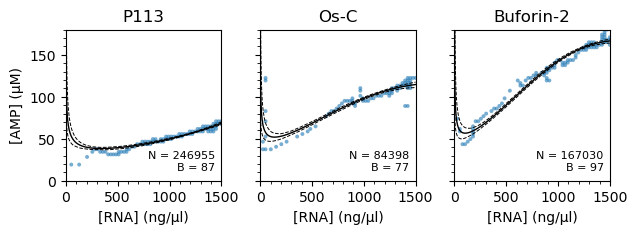

In [7]:
# ------------------------------------
# Plot: data + best-fit curve + bootstrap dashed envelope
# ------------------------------------

xx = np.linspace(1e-5, 1500, 8000)

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(6.8, 2.1))

def model_panel(xx, theta, i):
    s = theta[0]
    b = theta[1]
    c = theta[2 + 2*i]
    p = theta[3 + 2*i]
    return s * xx**(-b) * np.exp(c * xx * np.exp(-p * xx))

for i, ax in enumerate(axes):
    _x = _x_list[i]
    _y = _y_list[i]

    # data
    ax.scatter(_x, _y, s=8, edgecolor='none', color='tab:blue', alpha=0.6)

    # best-fit curve
    y_fit = model_panel(xx, popt_g, i)
    ax.plot(xx, y_fit, color="black", lw=1.0, zorder=6)

    # bootstrap dashed envelope
    if boot_params is not None and len(boot_params) > 0:
        Y = np.array([model_panel(xx, th, i) for th in boot_params])

        # choose interval
        y_lo = np.percentile(Y, 5, axis=0)
        y_hi = np.percentile(Y, 95, axis=0)

        ax.plot(xx, y_hi, color="black", ls="--", lw=0.7, zorder=6)
        ax.plot(xx, np.clip(y_lo, 0, None), color="black", ls="--", lw=0.7, zorder=6)

    # labels / styling
    ax.set_title(variants[i])
    ax.set_xlabel(r"[RNA] (ng/µl)")
    if i == 0:
        ax.set_ylabel(r"[AMP] (µM)")

    ax.set_xlim(0, 1500)
    ax.set_ylim(0, 180)
    ax.minorticks_on()

    ax.text(
        0.96, 0.20,
        f"N = {N_RAW[i]}\nB = {N_BOUND[i]}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8
    )

plt.subplots_adjust(left=0.08, right=0.88, top=0.90, bottom=0.18, wspace=0.25)
plt.show()

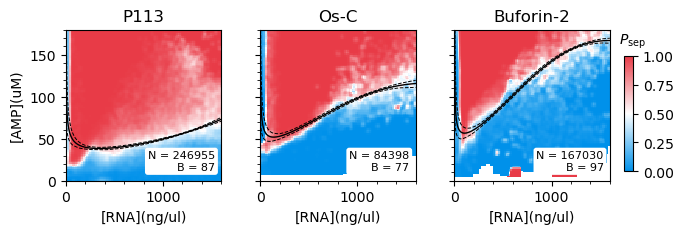

In [8]:
# create colormap
blue = "#0091ea"
light_blue = "#b3e5fc"

red = "#e83b47"
light_red = "#f18e86"

blue_cmap = LinearSegmentedColormap.from_list(
    "blue_red_custom",
    [   blue,        # low P_sep
        "#ffffff",   # midpoint ~0.5
        red          # high P_sep
    ] )


# ------------------------------------
# Plot heatmap raw data + ±1σ envelope
# ------------------------------------
xx = np.linspace(0.01, 1600, 8000)

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(6.8, 2.1))

for i, ax in enumerate(axes):
    section = dfs[i]

    im, res = phase_separation_probability(
        ax, section,
        xcol=key[i][0], ycol=key[i][1], f_col="feature",
        bins=100, smooth_sigma=1.0,
        cmap=blue_cmap, vmin=0.0, vmax=1.0
    )

    # parameters (UPDATED indexing)
    s = popt_g[0]
    b = popt_g[1]
    c = popt_g[2 + 2*i]
    p = popt_g[3 + 2*i]
    
    # mean curve (UPDATED model)
    y_fit = s * xx**(-b) * np.exp(c * xx * np.exp(-p * xx))
    ax.plot(xx, y_fit, color="black", lw=1.0, zorder=6)

    # bootstrap dashed envelope (already correct if model_panel updated)
    if boot_params is not None and len(boot_params) > 0:
        Y = np.array([model_panel(xx, th, i) for th in boot_params])

        y_lo = np.percentile(Y, 5, axis=0)
        y_hi = np.percentile(Y, 95, axis=0)

        ax.plot(xx, y_hi, color="black", ls="--", lw=0.7, zorder=6)
        ax.plot(xx, np.clip(y_lo, 0, None), color="black", ls="--", lw=0.7, zorder=6)

    # styling
    ax.set_title(f"{variants[i]}")
    ax.set_xlabel(lab[i][0])
    if i == 0:
        ax.set_ylabel(lab[i][1])

    ax.set_xlim(0, 1600)
    ax.set_ylim(0, 180)
    ax.minorticks_on()

    # data number counts
    ax.text(
        0.96, 0.20,
        f"N = {N_RAW[i]}\nB = {N_BOUND[i]}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=1.0),
        fontsize=8
    )

plt.subplots_adjust(left=0.08, right=0.88, top=0.90, bottom=0.18, wspace=0.25)

# colorbar
cbar_w, cbar_h = 0.014, 0.55
cax = fig.add_axes([0.90, 0.5 - 0.5*cbar_h, cbar_w, cbar_h])
cbar = fig.colorbar(im, cax=cax)
cbar.ax.text(
    1.0, 1.05, r"$P_{\mathrm{sep}}$",
    transform=cbar.ax.transAxes,
    ha="center", va="bottom", fontsize=10
)

plt.show()

In [9]:
# Read off model parameters
c_vals = np.array([popt_g[2 + 2*i] for i in range(3)])
p_vals = np.array([popt_g[3 + 2*i] for i in range(3)])

c_err = np.array([np.sqrt(pcov_g[2 + 2*i, 2 + 2*i]) for i in range(3)])
p_err = np.array([np.sqrt(pcov_g[3 + 2*i, 3 + 2*i]) for i in range(3)])

ratio_vals = p_vals / c_vals
ratio_err = ratio_vals * np.sqrt((p_err / p_vals)**2 + (c_err / c_vals)**2)

# Calculate physical quantities

# Three-body repulsion χ^(3)
repulsion_vals = c_vals / (1.8 * 0.01 * 10 * 1e4 * 0.01 * 0.47 * 1e-9)
repulsion_err = c_err / (1.8 * 0.01 * 10 * 1e4 * 0.01 * 0.47 * 1e-9)

# Competition Δχ
dchi_vals = p_vals / (1.8 * 0.01 * 1e4 * 1e4 * 0.47 * 1e-9)
dchi_err = p_err / (1.8 * 0.01 * 1e4 * 1e4 * 0.47 * 1e-9)

# AMP-RNA dissociation constant K_D (μM)
kd_vals = ratio_vals * ((2 * 0.01) / (1.8 * 0.01 * 1e4)) * 1e6
kd_err = ratio_err * ((2 * 0.01) / (1.8 * 0.01 * 1e4)) * 1e6


print("\n================== Calculated Physical Quantities =================\n")
for name, r, r_err, d, d_err, k, k_err in zip(
    variants,
    repulsion_vals, repulsion_err,
    dchi_vals, dchi_err,
    kd_vals, kd_err
):
    print(
        f"{name}: χ_3 = {r:.0f}±{r_err:.0f}, "
        f"Δχ = {d:.3f}±{d_err:.3f}, "
        f"K_D = {k:.3f}±{k_err:.3f} μM"
    )
    print()




================== Calculated Physical Quantities =================

P113: χ_3 = 107823±33103, Δχ = 0.012±0.161, K_D = 1.218±16.622 μM

Os-C: χ_3 = 303679±36889, Δχ = 0.572±0.040, K_D = 20.938±2.942 μM

Buforin-2: χ_3 = 397878±36519, Δχ = 0.641±0.021, K_D = 17.908±1.749 μM



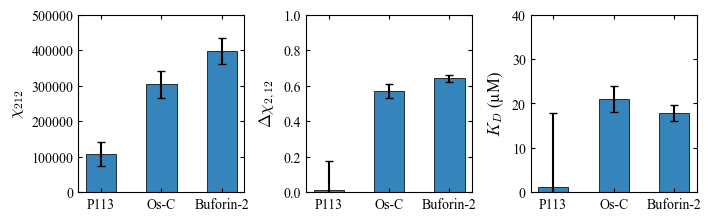

In [10]:
# Plot the inferred physical quantities
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "errorbar.capsize": 2.5,
})

# --------------------------------------------------------------
# Three subplots: χ^(3), Δχ and K_D
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.1), constrained_layout=True)
bar_width = 0.5

# Colors for bars
colors = ['tab:blue','tab:blue','tab:blue']

# Three-body parameter χ^(3)
axes[0].bar(variants, repulsion_vals, yerr=repulsion_err, width=bar_width, color=colors,
            edgecolor='k', alpha=0.9, linewidth=0.6, capsize=3)
axes[0].set_ylabel(r"$\chi_{212}$")
axes[0].set_ylim(0, 5*1e5)
#axes[0].set_yscale('log')
#axes[0].text(0.05, 0.93, transform=axes[0].transAxes, fontweight='bold')


# Comptition Δχ
axes[1].bar(variants, dchi_vals, yerr=dchi_err, width=bar_width, color=colors,
            edgecolor='k', alpha=0.9, linewidth=0.6, capsize=3)
axes[1].set_ylabel(r"$\Delta\chi_{2,12}$")
axes[1].set_ylim(0, 1.0)
#axes[1].text(0.05, 0.93, transform=axes[1].transAxes, fontweight='bold')

# Dissociation constant K_D
axes[2].bar(variants, kd_vals, yerr=kd_err, width=bar_width, color=colors,
            edgecolor='k', alpha=0.9, linewidth=0.6, capsize=3)
axes[2].set_ylabel(r"$K_D$ (µM)")
axes[2].set_ylim(0, 40)
#axes[2].text(0.05, 0.93, transform=axes[2].transAxes, fontweight='bold')

# Axis
for ax in axes:
    ax.tick_params(which='both', direction='in')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

plt.show()


In [11]:
def panel_label(ax, text, x=-0.20, y=1.10, fontsize=11, bold=False):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        clip_on=False
    )


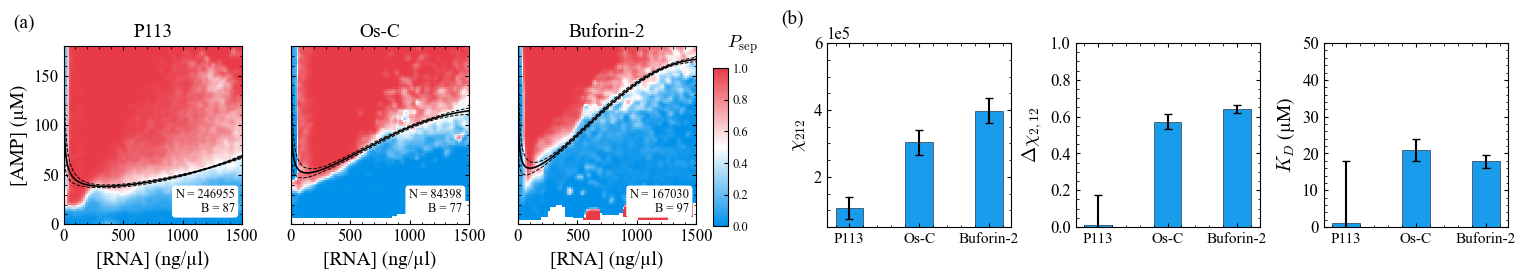

In [12]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})


# ==========================================================
# Layout Control: (a) left 3 + colorbar | (b) right 3
# ==========================================================
AX = 2.0                 # square panel width (inches)
WSPACE_INNER = 0.35     # SAME spacing for both (a) and (b)
GUTTER = 0.70           # physical gap between (a) and (b)
CBAR_FRAC = 0.10        # colorbar width relative to one panel

# ----------------------------------------------------------
# Derived geometry
# ----------------------------------------------------------
gap = WSPACE_INNER * AX

# width of 3 panels
W3 = 3 * AX + 2 * gap

# left block includes colorbar
W_left_total = W3 + CBAR_FRAC * AX
W_right_total = W3

FIG_W = W_left_total + GUTTER + W_right_total
FIG_H = AX + 0.6        # controlled vertical padding

# ----------------------------------------------------------
# Figure + outer grid (CRITICAL: fixed margins)
# ----------------------------------------------------------
fig = plt.figure(figsize=(FIG_W, FIG_H))

gs = fig.add_gridspec(
    nrows=1, ncols=3,
    width_ratios=[W_left_total, GUTTER, W_right_total],
    wspace=0.0,
    left=0.06,
    right=0.98,
    bottom=0.18,
    top=0.92
)

# ----------------------------------------------------------
# (a): 3 panels + colorbar (aligned internally)
# ----------------------------------------------------------
gs_left = gs[0].subgridspec(
    1, 4,
    width_ratios=[1, 1, 1, CBAR_FRAC],
    wspace=WSPACE_INNER
)

ax_top = [fig.add_subplot(gs_left[0, j]) for j in range(3)]
cax = fig.add_subplot(gs_left[0, 3])

# ----------------------------------------------------------
# (b): 3 panels
# ----------------------------------------------------------
gs_right = gs[2].subgridspec(
    1, 3,
    wspace=WSPACE_INNER
)

ax_bot = [fig.add_subplot(gs_right[0, j]) for j in range(3)]

# ----------------------------------------------------------
# Enforce identical geometry
# ----------------------------------------------------------
for ax in ax_top + ax_bot:
    ax.set_box_aspect(1)


# ==========================================================
# Fig. 5(a): heatmap raw data + bootstrap envelope
# ==========================================================

xx = np.linspace(0.01, 1600, 8000)

def model_panel(xx, theta, i):
    s = theta[0]
    b = theta[1]
    c = theta[2 + 2*i]
    p = theta[3 + 2*i]
    return s * xx**(-b) * np.exp(c * xx * np.exp(-p * xx))

im = None  # keep handle for colorbar

for i, ax in enumerate(ax_top):
    df = dfs[i]

    im, res = phase_separation_probability(
        ax, df,
        xcol=key[i][0], ycol=key[i][1], f_col="feature",
        bins=100, smooth_sigma=1.0,
        cmap=blue_cmap, vmin=0.0, vmax=1.0
    )

    # best-fit mean curve
    y_fit = model_panel(xx, popt_g, i)
    ax.plot(xx, y_fit, color="black", lw=1.2, zorder=6)

    # envelope
    if boot_params is not None and len(boot_params) > 0:
        Y = np.array([model_panel(xx, th, i) for th in boot_params])
        y_lo = np.percentile(Y, 5, axis=0)
        y_hi = np.percentile(Y, 95, axis=0)

        ax.plot(xx, y_hi, color="black", ls="--", lw=0.7, zorder=6)
        ax.plot(xx, np.clip(y_lo, 0, None), color="black", ls="--", lw=0.7, zorder=6)

    # styling
    ax.set_title(variants[i])
    ax.set_xlabel(r"[RNA] (ng/µl)")
    if i == 0:
        ax.set_ylabel(r"[AMP] (µM)")
    else:
        ax.set_yticklabels([])

    ax.set_xlim(0, 1500)
    ax.set_ylim(0, 180)
    ax.set_xticks([0, 500, 1000, 1500])
    ax.minorticks_on()

    # data number counts
    ax.text(
        0.96, 0.20,
        f"N = {N_RAW[i]}\nB = {N_BOUND[i]}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=1.0
        ),
        fontsize=9
    )

# colorbar to the right of panel (a)
pos = cax.get_position()

# Example adjustments
cax.set_position([
    pos.x0 - 0.02,   # move right (+) or left (-)
    pos.y0 + 0.02,    # move up (+) or down (-)
    pos.width * 0.8,  # make thinner (<1) or thicker (>1)
    pos.height * 0.82  # shrink or stretch vertically
])

cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(direction="in", labelsize=9)
cbar.ax.text(
    2.0, 1.08, r"$P_{\mathrm{sep}}$",
    transform=cbar.ax.transAxes,
    ha="center", va="bottom", fontsize=13
)

panel_label(ax_top[0], "(a)", x=-0.28, y=1.18, fontsize=14, bold=False)


# ==========================================================
# Fig. 5(b): bar charts
# ==========================================================
bar_width = 0.40

ax = ax_bot[0]
ax.bar(variants, repulsion_vals, yerr=repulsion_err, width=bar_width,
       color='#0091ea', edgecolor="k", alpha=0.9, linewidth=0.4, capsize=3)
ax.set_ylabel(r"$\chi_{212}$")
ax.set_ylim(5*1e4, 6*1e5)
#ax.set_yscale('log')
ax.ticklabel_format(axis='y', style='sci', scilimits=(5,5))
ax.tick_params(axis='x', labelsize=11)
ax.minorticks_on()

ax = ax_bot[1]
ax.bar(variants, dchi_vals, yerr=dchi_err, width=bar_width,
       color='#0091ea', edgecolor="k", alpha=0.9, linewidth=0.4, capsize=3)
ax.set_ylabel(r"$\Delta\chi_{2,12}$")
ax.set_ylim(0, 1)
ax.tick_params(axis='x', labelsize=11)
ax.minorticks_on()

ax = ax_bot[2]
ax.bar(variants, kd_vals, yerr=kd_err, width=bar_width,
       color='#0091ea', edgecolor="k", alpha=0.9, linewidth=0.4, capsize=3)
ax.set_ylabel(r"$K_D$ (µM)")
ax.set_ylim(0, 50)
ax.tick_params(axis='x', labelsize=11)
ax.minorticks_on()

panel_label(ax_bot[0], "(b)", x=-0.25, y=1.18, fontsize=14, bold=False)


for ax in ax_top + ax_bot:
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


# ==========================================================
# Export
# ==========================================================
#fig.savefig("Figure_5.pdf", bbox_inches="tight")
#fig.savefig("Figure_5.png", dpi=600)
plt.show()